# EDA
Cleaned Dataset Analysis
- 425k+ records across states and areas
- AQI values and quality status distributions
- Temporal and geographic patterns
- Pollutant analysis by region

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

data = pd.read_csv('../Data/processed/clean_data.csv')
print(f"Shape ->> {data.shape}")
print(f"\nColumns ->> {data.columns.tolist()}")


Shape ->> (425138, 13)

Columns ->> ['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'year', 'month', 'day', 'day_of_week', 'quality_level']


In [18]:
print(f"\nFirst few rows:")
print(data.head())


First few rows:
         date           state       area  number_of_monitoring_stations  \
0  2025-06-19   uttar pradesh       agra                            5.0   
1  2025-06-19       karnataka   bagalkot                            1.0   
2  2025-06-19     maharashtra      akola                            1.0   
3  2025-06-19       rajasthan      alwar                            1.0   
4  2025-06-19  andhra pradesh  amaravati                            1.0   

  prominent_pollutants  aqi_value air_quality_status  \
0        O3,PM2.5,PM10         49               Good   
1                 PM10         46               Good   
2                 PM10         26               Good   
3                   CO         76       Satisfactory   
4                 PM10         66       Satisfactory   

                                                unit  year  month  day  \
0  number_of_monitoring_stations in Absolute Numb...  2025      6   19   
1  number_of_monitoring_stations in Absolute Nu

In [3]:

print("<<<--- Dataset Overview -->>>\n")
print(data.info())
print("<<-- Missing values -->>\n")
print(data.isnull().sum())


<<<--- Dataset Overview -->>>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425138 entries, 0 to 425137
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           425138 non-null  object 
 1   state                          425138 non-null  object 
 2   area                           425138 non-null  object 
 3   number_of_monitoring_stations  425138 non-null  float64
 4   prominent_pollutants           425138 non-null  object 
 5   aqi_value                      425138 non-null  int64  
 6   air_quality_status             425138 non-null  object 
 7   unit                           425138 non-null  object 
 8   year                           425138 non-null  int64  
 9   month                          425138 non-null  int64  
 10  day                            425138 non-null  int64  
 11  day_of_week                    425138 non-null  object 
 12 

In [5]:
print("<<<---- Air Quality Status Distribution -->>>")
print(data['air_quality_status'].value_counts())
print("\n<<---- Percentage ->>>")

c = data['air_quality_status'].value_counts()

Total = len(data)
per = (c / Total) * 100

print(per.round(2))

<<<---- Air Quality Status Distribution -->>>
air_quality_status
Satisfactory    155167
Moderate        138489
Good             69750
Poor             43784
Very Poor        15384
Severe            2564
Name: count, dtype: int64

<<---- Percentage ->>>
air_quality_status
Satisfactory    36.50
Moderate        32.58
Good            16.41
Poor            10.30
Very Poor        3.62
Severe           0.60
Name: count, dtype: float64


## Air Quality Status Distribution

## Visualization 1

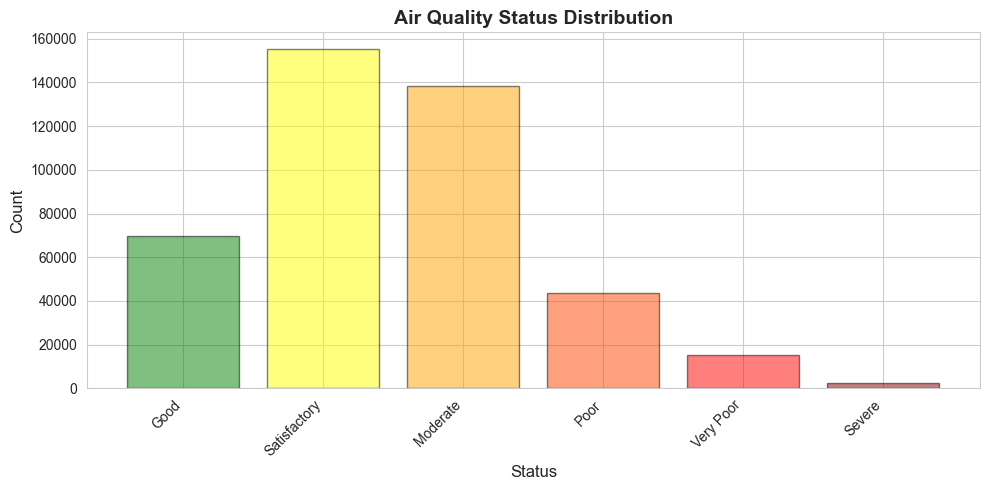

<<--- Count Status-->>
  Good: 69,750
  Satisfactory: 155,167
  Moderate: 138,489
  Poor: 43,784
  Very Poor: 15,384
  Severe: 2,564


In [6]:
status = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
status_counts = data['air_quality_status'].value_counts().reindex(status)

plt.figure(figsize=(10, 5))
colors = ['green', 'yellow', 'orange', 'orangered', 'red', 'darkred']
plt.bar(status, status_counts.values, color=colors, alpha=0.5, edgecolor='black')
plt.title("Air Quality Status Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("<<--- Count Status-->>")
for s, count in zip(status, status_counts.values):
    print(f"  {s}: {count:,}")

## Visualization 2 - AQI Value Distribution

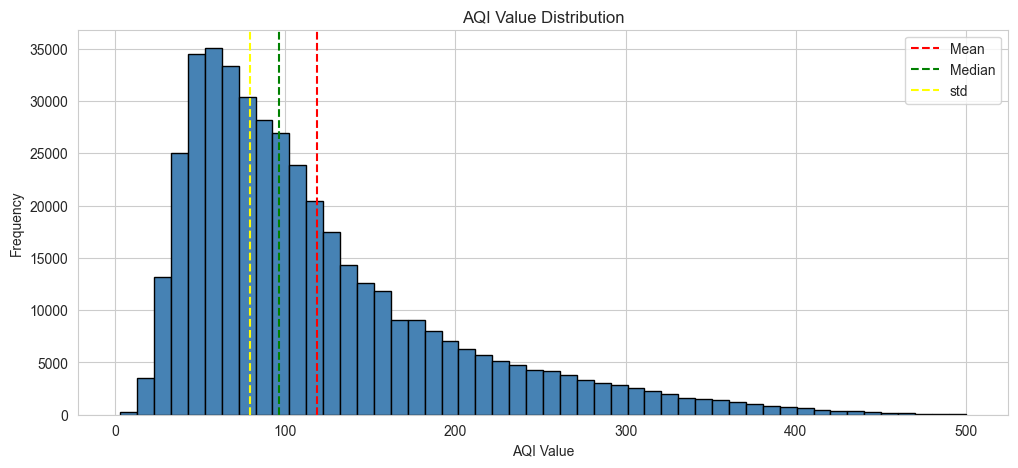

Mean: 118.65
Median: 96.00
Std Dev: 79.49


In [7]:
plt.figure(figsize=(12, 5))
plt.hist(data['aqi_value'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(data['aqi_value'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(data['aqi_value'].median(), color='green', linestyle='--', label='Median')
plt.axvline(data['aqi_value'].std(), color='yellow', linestyle='--', label='std')
plt.title("AQI Value Distribution")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Mean: {data['aqi_value'].mean():.2f}")
print(f"Median: {data['aqi_value'].median():.2f}")
print(f"Std Dev: {data['aqi_value'].std():.2f}")

## Visualization 3 - Top 15 States by Average AQI

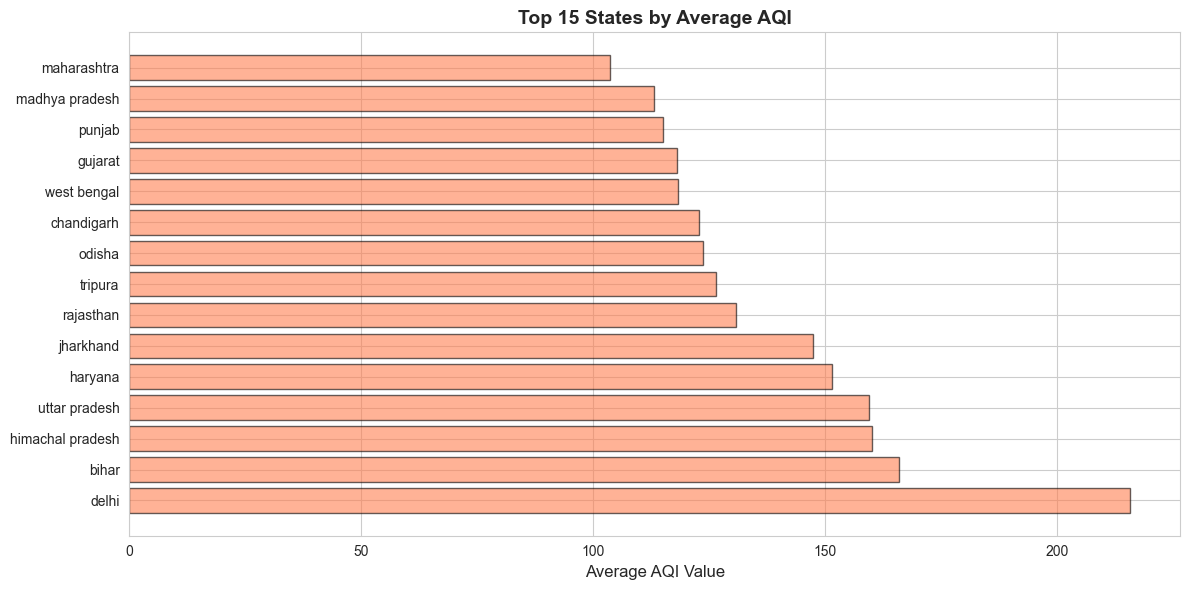

Top 15 States by Average AQI:
state
delhi               215.759684
bihar               165.905256
himachal pradesh    160.133040
uttar pradesh       159.574449
haryana             151.491985
jharkhand           147.367081
rajasthan           130.720200
tripura             126.565670
odisha              123.680314
chandigarh          122.829909
west bengal         118.290586
gujarat             117.990839
punjab              115.075731
madhya pradesh      113.111504
maharashtra         103.663386
Name: aqi_value, dtype: float64


In [11]:
state_aqi = data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(state_aqi.index, state_aqi.values, color='coral', edgecolor='black', alpha=0.6)
plt.title("Top 15 States by Average AQI", fontsize=14, fontweight='bold')
plt.xlabel("Average AQI Value", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 15 States by Average AQI:")
print(state_aqi)

## Visualization 4 - Box Plot by Quality Status

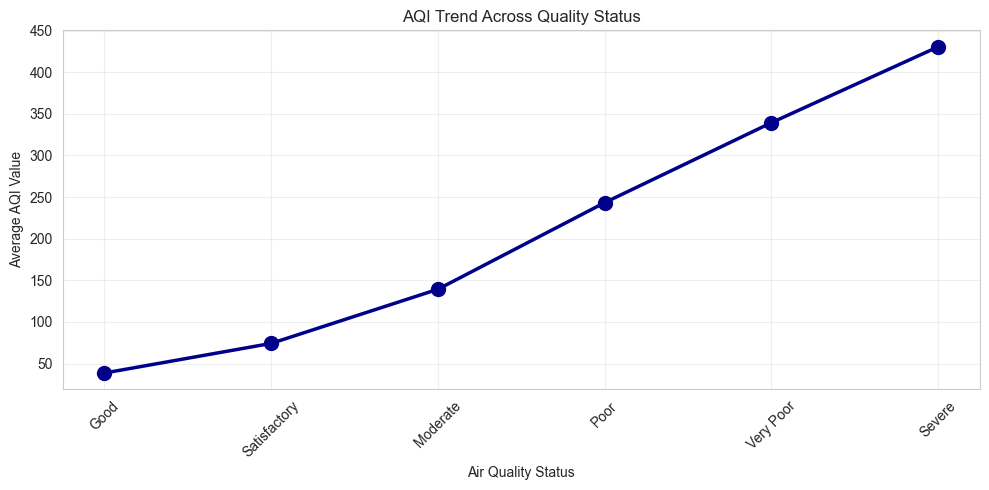


Average AQI by Status:
air_quality_status
Good             38.529677
Satisfactory     74.118066
Moderate        139.205569
Poor            243.288690
Very Poor       339.402626
Severe          430.609594
Name: aqi_value, dtype: float64


In [12]:
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
status_avg = data.groupby('air_quality_status')['aqi_value'].mean().reindex(status_order)

plt.figure(figsize=(10, 5))
plt.plot(status_avg.index, status_avg.values, marker='o', linewidth=2.5, markersize=10, color='darkblue')
plt.title("AQI Trend Across Quality Status")
plt.xlabel("Air Quality Status")
plt.ylabel("Average AQI Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAverage AQI by Status:")
print(status_avg)

## Visualization 5 - Monthly Trends

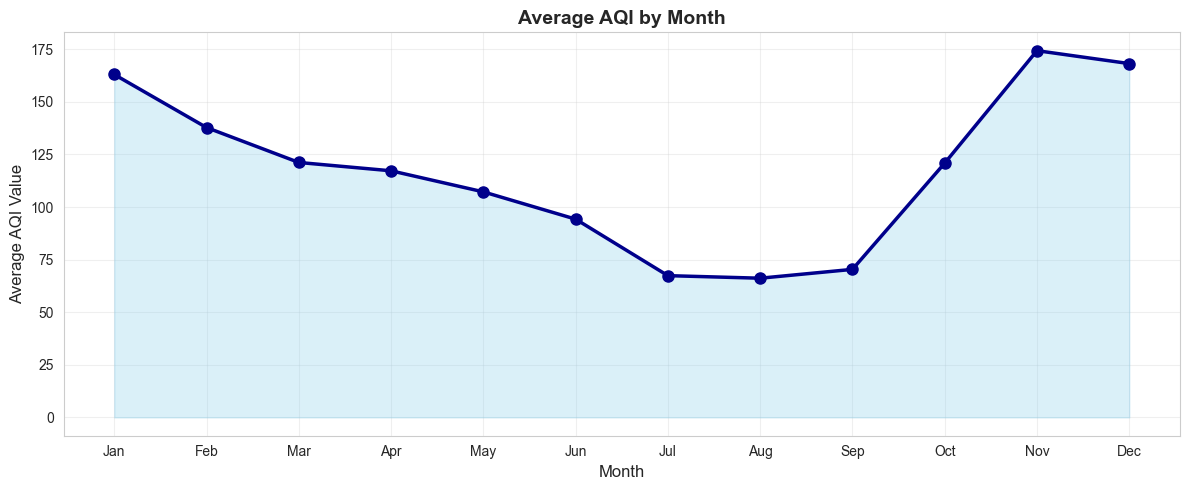

Average AQI by Month:
             mean  count
month                   
1      162.985960  37036
2      137.772164  34775
3      121.170215  38980
4      117.209994  36963
5      107.195227  38135
6       94.231228  34892
7       67.372855  32168
8       66.156819  32681
9       70.357121  32426
10     120.866562  34900
11     174.313503  35400
12     168.171307  36782


In [13]:
monthly_aqi = data.groupby('month')['aqi_value'].agg(['mean', 'count'])

plt.figure(figsize=(12, 5))
plt.plot(monthly_aqi.index, monthly_aqi['mean'], marker='o', linewidth=2.5, markersize=8, color='darkblue')
plt.fill_between(monthly_aqi.index, monthly_aqi['mean'], alpha=0.3, color='skyblue')
plt.title("Average AQI by Month", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average AQI Value", fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average AQI by Month:")
print(monthly_aqi)

In [14]:
state_monthly_aqi = data.groupby(['state', 'month'])['aqi_value'].mean()
print("State-wise Monthly AQI:")
print(state_monthly_aqi.head(10))

year_monthly_aqi = data.groupby(['year', 'month'])['aqi_value'].mean()
print("\nYear-wise Monthly AQI:")
print(year_monthly_aqi)

State-wise Monthly AQI:
state                        month
andaman and nicobar islands  2         67.285714
                             3         66.920000
                             4         46.269231
                             5         64.533333
                             6         69.909091
andhra pradesh               1        123.793103
                             2         98.842563
                             3         80.594401
                             4         69.884236
                             5         70.395100
Name: aqi_value, dtype: float64

Year-wise Monthly AQI:
year  month
2015  5        142.898305
      6        113.752613
      7         86.963855
      8         85.394118
      9        109.915119
                  ...    
2025  2        112.270384
      3        105.054656
      4         98.976935
      5         80.268166
      6         79.632890
Name: aqi_value, Length: 122, dtype: float64


## Visualization 6 - Monitoring Stations by State

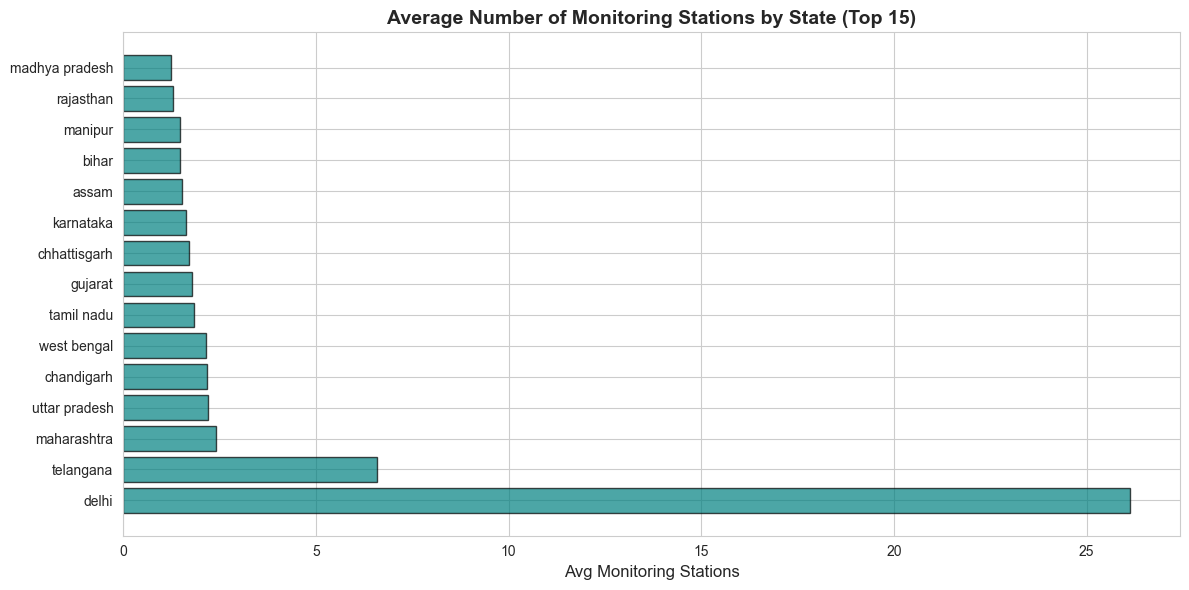


Top 15 States by Total Monitoring Stations:
 1. delhi                     -> 26
 2. telangana                 -> 6
 3. maharashtra               -> 2
 4. uttar pradesh             -> 2
 5. chandigarh                -> 2
 6. west bengal               -> 2
 7. tamil nadu                -> 1
 8. gujarat                   -> 1
 9. chhattisgarh              -> 1
10. karnataka                 -> 1
11. assam                     -> 1
12. bihar                     -> 1
13. manipur                   -> 1
14. rajasthan                 -> 1
15. madhya pradesh            -> 1


In [15]:
stations_by_state = data.groupby('state')['number_of_monitoring_stations'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(stations_by_state.index, stations_by_state.values, color='teal', edgecolor='black', alpha=0.7)
plt.title("Average Number of Monitoring Stations by State (Top 15)", fontsize=14, fontweight='bold')
plt.xlabel("Avg Monitoring Stations", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 15 States by Total Monitoring Stations:")
for rank, (state, value) in enumerate(stations_by_state.items(), 1):
    print(f"{rank:2d}. {state:25} -> {int(value)}")

## Summary


In [16]:

status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

print("\n1. Top 5 Worst Performing States (Highest AQI):")
print(data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(5))

print("\n2. Top 5 Best Performing States (Lowest AQI):")
print(data.groupby('state')['aqi_value'].mean().sort_values(ascending=True).head(5))

print("\n3. Air Quality Status Breakdown:")
status_dist = data['air_quality_status'].value_counts()
for status, count in status_dist.items():
    print(f"   {status}: {count:,} ({count/len(data)*100:.1f}%)")

print("\n4. Quality Level by Status:")
for status in status_order:
    level = data[data['air_quality_status'] == status]['quality_level'].iloc[0] if status in data['air_quality_status'].values else "N/A"
    print(f"   {status}: Level {level}")

print("\n5. Peak Pollution Month:", data.groupby('month')['aqi_value'].mean().idxmax(), "(Avg AQI: {:.1f})".format(data.groupby('month')['aqi_value'].mean().max()))

print("\n6. Cleanest Month:", data.groupby('month')['aqi_value'].mean().idxmin(), "(Avg AQI: {:.1f})".format(data.groupby('month')['aqi_value'].mean().min()))


1. Top 5 Worst Performing States (Highest AQI):
state
delhi               215.759684
bihar               165.905256
himachal pradesh    160.133040
uttar pradesh       159.574449
haryana             151.491985
Name: aqi_value, dtype: float64

2. Top 5 Best Performing States (Lowest AQI):
state
mizoram              45.059902
meghalaya            52.616343
sikkim               53.469505
puducherry           55.957572
arunachal pradesh    59.861194
Name: aqi_value, dtype: float64

3. Air Quality Status Breakdown:
   Satisfactory: 155,167 (36.5%)
   Moderate: 138,489 (32.6%)
   Good: 69,750 (16.4%)
   Poor: 43,784 (10.3%)
   Very Poor: 15,384 (3.6%)
   Severe: 2,564 (0.6%)

4. Quality Level by Status:
   Good: Level 1
   Satisfactory: Level 2
   Moderate: Level 3
   Poor: Level 4
   Very Poor: Level 5
   Severe: Level 6

5. Peak Pollution Month: 11 (Avg AQI: 174.3)

6. Cleanest Month: 8 (Avg AQI: 66.2)
